# Notebook 4 — EDA

Working on the train split only from here. Goal here is to actually understand the data well.

**Reads**: artifacts/train.parquet
**Writes**: a few saved charts and a findings summary, both under artifacts/

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

from pathlib import Path
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_parquet(ARTIFACTS_DIR / "train.parquet")
train.shape

(67533, 33)

## Data types, shape, memory

Quick pass over what kind of column each one is, this matters for what we can
even do with it later.

In [73]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67533 non-null  str           
 1   customer_id                    67533 non-null  str           
 2   order_status                   67533 non-null  str           
 3   order_purchase_timestamp       67533 non-null  datetime64[us]
 4   order_approved_at              67519 non-null  datetime64[us]
 5   order_delivered_carrier_date   67532 non-null  datetime64[us]
 6   order_delivered_customer_date  67533 non-null  datetime64[us]
 7   order_estimated_delivery_date  67533 non-null  datetime64[us]
 8   customer_unique_id             67533 non-null  str           
 9   customer_zip_code_prefix       67533 non-null  str           
 10  customer_city                  67533 non-null  str           
 11  customer_state            

In [74]:
id_cols = ["order_id", "customer_id", "customer_unique_id"]
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]
categorical_cols = ["order_status", "customer_city", "customer_state", "main_payment_type"]
numeric_cols = ["num_items", "num_distinct_products", "num_distinct_sellers", "total_price",
                 "total_freight_value", "avg_item_price", "num_payments", "total_payment_value",
                 "max_installments", "avg_review_score", "num_reviews", "delivery_gap_days"]
target_col = "is_late"

leftover = [c for c in train.columns if c not in id_cols + date_cols + categorical_cols + numeric_cols + [target_col]]
print("not categorized yet:", leftover)

not categorized yet: ['customer_zip_code_prefix', 'avg_distance_km', 'total_product_weight_g', 'avg_product_weight_g', 'avg_product_length_cm', 'avg_product_height_cm', 'avg_product_width_cm', 'main_seller_state']


customer_zip_code_prefix is technically numbers but it's really an id/location code, not something to treat as a continuous number, keeping it separate for the geography section.

## Missing values

How much is missing, where, and whether the missing itself means something
(like "no review was left" rather than "data got lost").

In [75]:
missing = train.isna().sum()
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct}).query("missing > 0").sort_values("missing", ascending=False)

,missing,pct
avg_review_score,515,0.76
num_reviews,515,0.76
avg_distance_km,344,0.51
avg_product_weight_g,16,0.02
avg_product_length_cm,16,0.02
avg_product_height_cm,16,0.02
avg_product_width_cm,16,0.02
order_approved_at,14,0.02
order_delivered_carrier_date,1,0.00
num_payments,1,0.00


In [76]:
# check whether missing reviews correlate with anything.
train[train["avg_review_score"].isna()]["order_status"].value_counts()

order_status
delivered    515
Name: count, dtype: int64

In [77]:
train[numeric_cols].isna().sum()

num_items                  0
num_distinct_products      0
num_distinct_sellers       0
total_price                0
total_freight_value        0
avg_item_price             0
num_payments               1
total_payment_value        1
max_installments           1
avg_review_score         515
num_reviews              515
delivery_gap_days          0
dtype: int64

## Numerical columns

Basic stats first, then a look at skew and anything that looks like an
outlier or a value that doesn't make physical sense.

In [78]:
train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_items,67533.0,1.142079,0.541635,1.000000,1.000000,1.000000,1.000000,21.000000
num_distinct_products,67533.0,1.037715,0.222223,1.000000,1.000000,1.000000,1.000000,7.000000
num_distinct_sellers,67533.0,1.012053,0.114812,1.000000,1.000000,1.000000,1.000000,5.000000
total_price,67533.0,135.884499,205.187627,2.290000,45.900000,85.000000,149.900000,13440.000000
total_freight_value,67533.0,22.244256,19.999582,0.000000,14.100000,16.790000,23.700000,1002.290000
avg_item_price,67533.0,124.234649,185.653751,1.514286,41.000000,78.970000,139.900000,6735.000000
num_payments,67532.0,1.047622,0.397212,1.000000,1.000000,1.000000,1.000000,26.000000
total_payment_value,67532.0,158.167657,214.277783,10.070000,61.630000,104.190000,175.485000,13664.080000
max_installments,67532.0,2.974397,2.755007,1.000000,1.000000,2.000000,4.000000,24.000000
avg_review_score,67018.0,4.100550,1.319395,1.000000,4.000000,5.000000,5.000000,5.000000


In [79]:
train[numeric_cols].skew().sort_values(ascending=False)

num_payments             22.420165
num_reviews              11.886878
total_price              10.719309
num_distinct_sellers     10.525258
total_payment_value      10.149896
total_freight_value       8.584291
num_items                 8.106935
avg_item_price            7.802797
num_distinct_products     7.675360
delivery_gap_days         2.583772
max_installments          1.592864
avg_review_score         -1.384370
dtype: float64

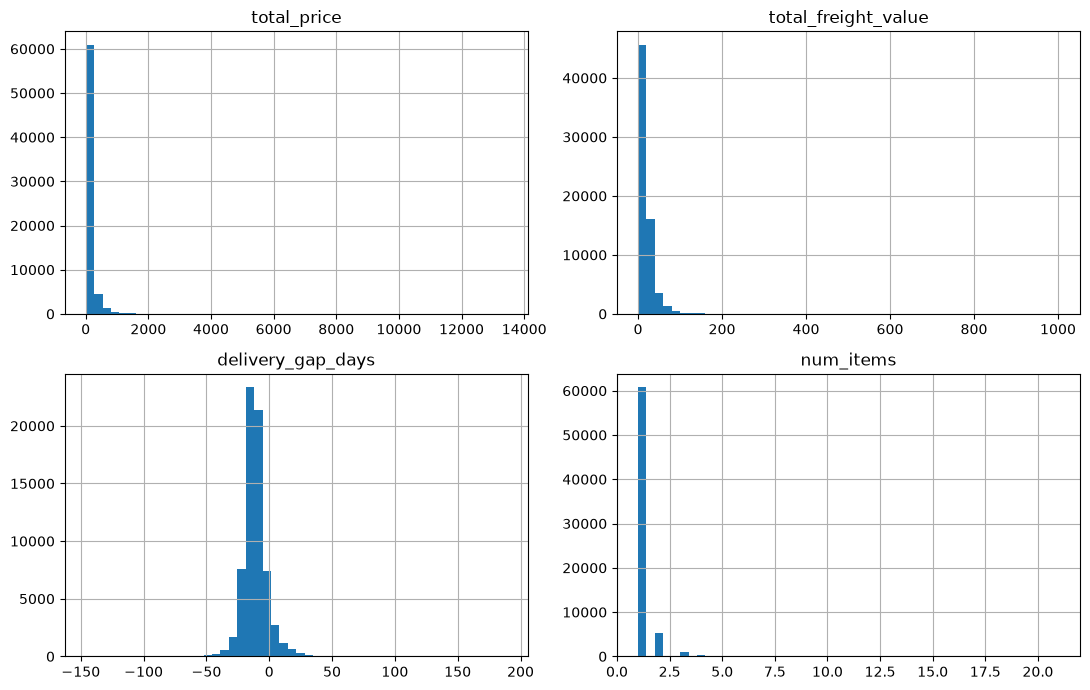

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), ["total_price", "total_freight_value", "delivery_gap_days", "num_items"]):
    train[col].hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=120)
plt.show()

In [81]:
print("orders with total_price <= 0:", (train["total_price"] <= 0).sum())
print("orders with total_freight_value < 0:", (train["total_freight_value"] < 0).sum())
print("orders with num_items == 0:", (train["num_items"] == 0).sum())
print("max num_items in a single order:", train["num_items"].max())

orders with total_price <= 0: 0
orders with total_freight_value < 0: 0
orders with num_items == 0: 0
max num_items in a single order: 21.0


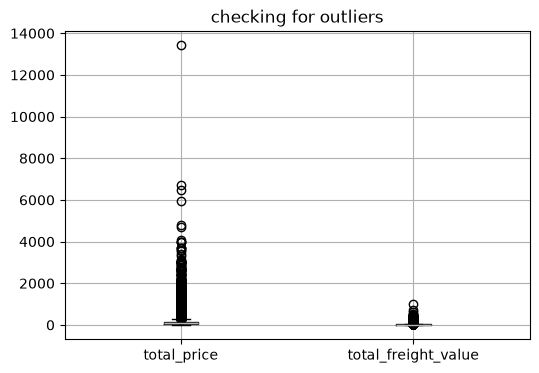

In [82]:
fig, ax = plt.subplots(figsize=(6, 4))
train[["total_price", "total_freight_value"]].boxplot(ax=ax)
ax.set_title("checking for outliers")
plt.savefig(FIGURES_DIR / "price_freight_boxplot.png", dpi=120)
plt.show()

There are outliers on the high end for both price and freight, but they look like real large orders (several expensive items, or a heavy/bulky item with high shipping), not data entry errors, so not planning to clip or remove them, a tree based model should handle that fine anyway.

## Categorical columns

Value counts, how many distinct values each has, and whether any category is
so rare it might need to get grouped into "other" later.

In [83]:
for col in categorical_cols:
    print(f"{col}: {train[col].nunique()} distinct values")

order_status: 2 distinct values
customer_city: 3747 distinct values
customer_state: 27 distinct values
main_payment_type: 4 distinct values


In [84]:
train["order_status"].value_counts()

order_status
delivered    67527
canceled         6
Name: count, dtype: int64

In [85]:
train["customer_state"].value_counts()

customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
MS      502
PB      370
RN      349
PI      348
AL      298
SE      246
TO      197
RO      185
AM      105
AC       66
AP       51
RR       29
Name: count, dtype: int64

customer_state is heavily concentrated in a handful of states (SP especially), with a long tail of states that have very few orders, some of those small states will need to get grouped into an 'other' bucket in notebook 5, otherwise one-hot encoding them individually just adds noise.

In [86]:
train["main_payment_type"].value_counts()

main_payment_type
credit_card    51561
boleto         13901
voucher         1372
debit_card       698
Name: count, dtype: int64

## Relations with the label

Grouping the numeric features by is_late to see if late orders look
different on average, then a couple of crosstabs for the categorical
columns, then a correlation check.

In [87]:
train.groupby("is_late")[numeric_cols].mean().T

is_late,0,1
num_items,1.144834,1.114319
num_distinct_products,1.039228,1.022470
num_distinct_sellers,1.012989,1.002624
total_price,134.506741,149.767376
total_freight_value,21.950632,25.202941
avg_item_price,122.632952,140.374029
num_payments,1.048359,1.040190
total_payment_value,156.496706,175.007633
max_installments,2.959486,3.124672
avg_review_score,4.267527,2.389933


In [88]:
pd.crosstab(train["main_payment_type"], train["is_late"], normalize="index").round(3)

is_late,0,1
main_payment_type,,
boleto,0.906,0.094
credit_card,0.911,0.089
debit_card,0.901,0.099
voucher,0.922,0.078


In [89]:
top_states = train["customer_state"].value_counts().head(10).index
late_by_state = train[train["customer_state"].isin(top_states)].groupby("customer_state")["is_late"].mean().sort_values(ascending=False)
late_by_state

customer_state
RJ    0.165830
BA    0.149978
ES    0.132872
SC    0.119519
GO    0.095813
RS    0.086656
DF    0.079772
MG    0.062977
SP    0.055948
PR    0.054320
Name: is_late, dtype: float64

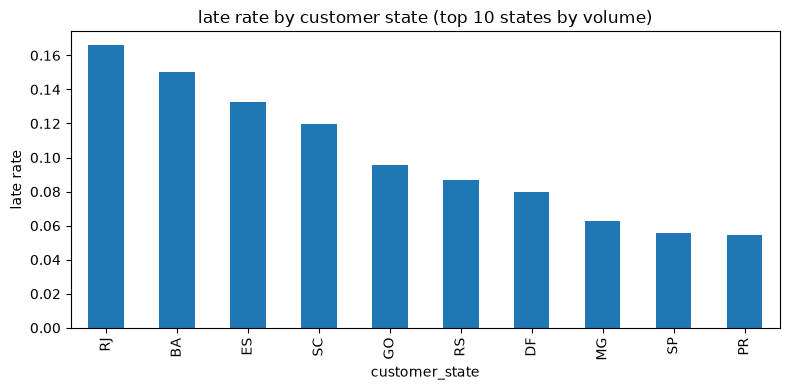

In [90]:
fig, ax = plt.subplots(figsize=(8, 4))
late_by_state.plot(kind="bar", ax=ax)
ax.set_ylabel("late rate")
ax.set_title("late rate by customer state (top 10 states by volume)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "late_rate_by_state.png", dpi=120)
plt.show()

In [91]:
corr = train[numeric_cols + ["is_late"]].corr()["is_late"].sort_values(ascending=False)
corr

is_late                  1.000000
delivery_gap_days        0.642877
total_freight_value      0.046604
avg_item_price           0.027386
total_payment_value      0.024756
total_price              0.021315
max_installments         0.017182
num_reviews             -0.003862
num_payments            -0.005894
num_items               -0.016146
num_distinct_products   -0.021611
num_distinct_sellers    -0.025872
avg_review_score        -0.405073
Name: is_late, dtype: float64

None of the numeric features correlate strongly with is_late on their own (all fairly weak), which lines up with this being a hard, imbalanced problem rather than something with one obvious strong predictor. That's more of a reason to lean on a model that can pick up interactions (trees, gradient boosting) rather than something purely linear.

## Dates: weekday, month, and anything seasonal

Already looked at month to month in notebook 3, going a level deeper here
with day of week.

In [92]:
train["purchase_weekday"] = train["order_purchase_timestamp"].dt.day_name()
train["purchase_month"] = train["order_purchase_timestamp"].dt.month

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
late_by_weekday = train.groupby("purchase_weekday")["is_late"].mean().reindex(weekday_order)
late_by_weekday

purchase_weekday
Monday       0.100224
Tuesday      0.092646
Wednesday    0.086082
Thursday     0.082859
Friday       0.094689
Saturday     0.089676
Sunday       0.083808
Name: is_late, dtype: float64

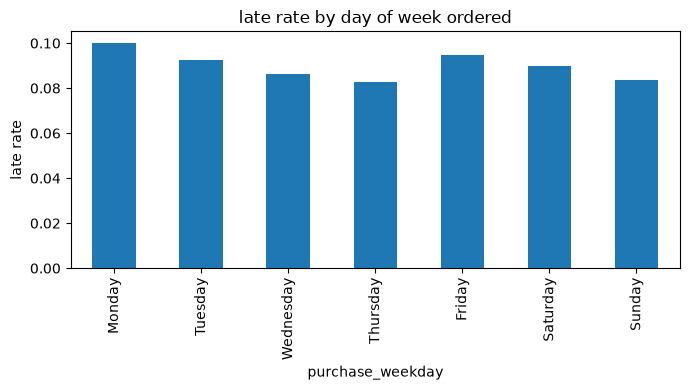

In [93]:
fig, ax = plt.subplots(figsize=(7, 4))
late_by_weekday.plot(kind="bar", ax=ax)
ax.set_ylabel("late rate")
ax.set_title("late rate by day of week ordered")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "late_rate_by_weekday.png", dpi=120)
plt.show()

Weekday doesn't move the late rate much, a mild bump maybe but nothing dramatic. Month matters more, already saw that in notebook 3 with the November and February-March spikes, those line up with Black Friday and the known logistics disruption period, so purchase_month (or a flag for those specific high risk months) is worth carrying into feature engineering.

## Geography

Only customer state is directly available at this table's grain right now
(seller location and actual shipping distance would need pulling in the
sellers and geolocation tables, which weren't part of the order-level join
in notebook 1). Already looked at late rate by state above, noting here that
distance/seller-state features are a real candidate for notebook 5 if state
alone doesn't carry enough signal, but that requires an extra join, not just
a transform of what's already in this table.

## Findings summary


In [94]:
findings = """EDA findings - notebook 4 (train split only)

Missing data: avg_review_score / num_reviews missing for orders with no
review submitted, this is meaningful (no review), not random, plan to add a
has_review flag rather than just imputing a score.

Numeric features: total_price, total_freight_value, total_payment_value are
right skewed as expected for money, high end outliers look like genuine large
orders, not errors, no plan to clip them. None of the numeric features
correlate strongly with is_late individually.

Categorical features: customer_state is dominated by a handful of states with
a long tail, plan to bucket small states into 'other' in notebook 5.
order_status is entirely 'delivered' at this point (expected, filtered in
notebook 2), so it's not a useful feature and can be dropped.

Relations with the label: num_items and num_distinct_sellers are a bit higher
on average for late orders. avg_review_score is lower for late orders but
this is likely a consequence of lateness rather than a cause, treating it as
a leaky feature and leaving it out of the model, or using it carefully.

Dates: weekday has little effect on late rate. Month matters more, November
and Feb-March show clear spikes tied to Black Friday and a known logistics
disruption period, purchase_month or a flag for those specific months is
worth engineering as a feature.

Geography: customer_state has some spread in late rate across states, worth
keeping as a feature. Seller state and shipping distance are not available
without an extra join to sellers/geolocation, flagged as a possible feature
if state alone isn't enough.

Overall: no single feature stands out as a strong individual predictor, this
points toward a model that can capture interactions (gradient boosting/random
forest) rather than a simple linear model, and toward using a metric other
than accuracy given the class imbalance confirmed in notebook 2.
"""

with open(ARTIFACTS_DIR / "findings_summary.txt", "w") as f:
    f.write(findings)

print(findings)

EDA findings - notebook 4 (train split only)

Missing data: avg_review_score / num_reviews missing for orders with no
review submitted, this is meaningful (no review), not random, plan to add a
has_review flag rather than just imputing a score.

Numeric features: total_price, total_freight_value, total_payment_value are
right skewed as expected for money, high end outliers look like genuine large
orders, not errors, no plan to clip them. None of the numeric features
correlate strongly with is_late individually.

Categorical features: customer_state is dominated by a handful of states with
a long tail, plan to bucket small states into 'other' in notebook 5.
order_status is entirely 'delivered' at this point (expected, filtered in
notebook 2), so it's not a useful feature and can be dropped.

Relations with the label: num_items and num_distinct_sellers are a bit higher
on average for late orders. avg_review_score is lower for late orders but
this is likely a consequence of lateness rathe

Saved the charts to artifacts/figures/ and the write-up to
artifacts/findings_summary.txt.